Starting experiments...

Belief Update Mode: pure_bayes

Training MDP with pure_bayes...
  Final cost: 227.77
  Training time: 46.8s

Training POMDP with pure_bayes...
  Final cost: 222.79
  Training time: 226.1s

Training Two-Stage with pure_bayes...
  Final cost: 218.56
  Training time: 70.1s

Belief Update Mode: anchored_bayes

Training MDP with anchored_bayes...
  Final cost: 203.63
  Training time: 46.4s

Training POMDP with anchored_bayes...
  Final cost: 206.68
  Training time: 225.1s

Training Two-Stage with anchored_bayes...
  Final cost: 209.34
  Training time: 109.5s

Belief Update Mode: markov

Training MDP with markov...
  Final cost: 203.37
  Training time: 46.5s

Training POMDP with markov...
  Final cost: 206.02
  Training time: 223.2s

Training Two-Stage with markov...
  Final cost: 202.47
  Training time: 70.5s

Generating plots...


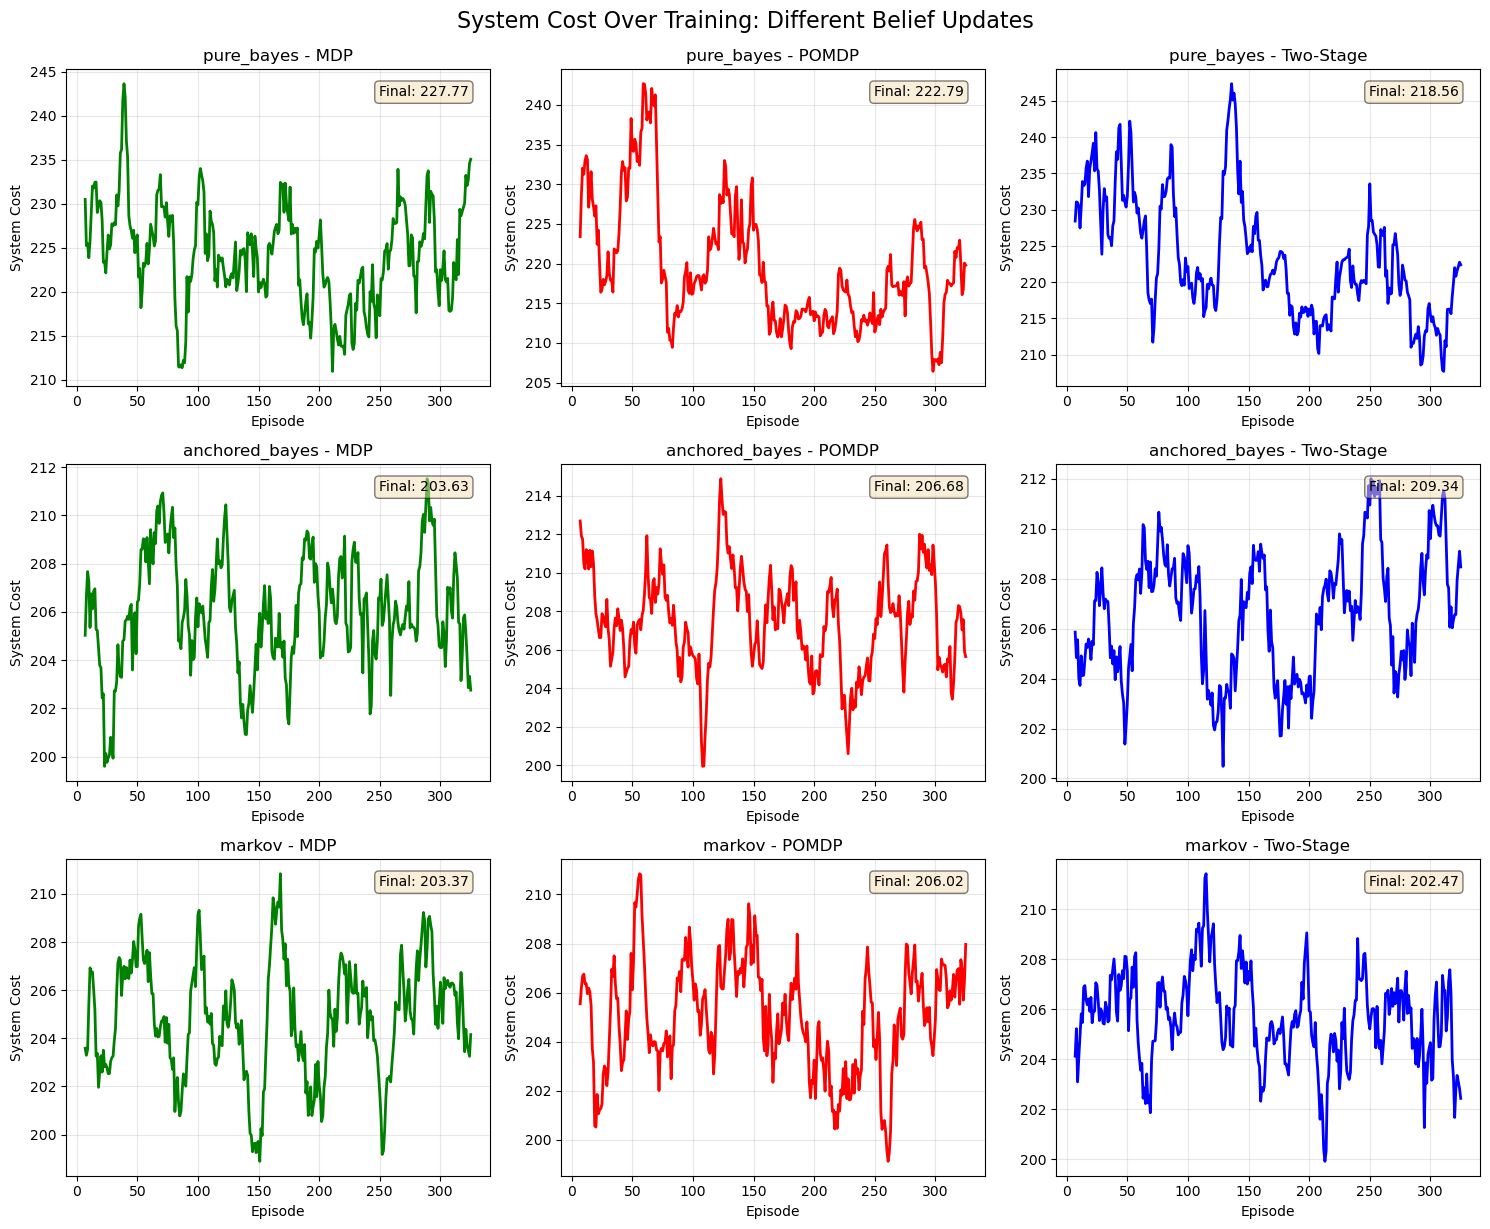

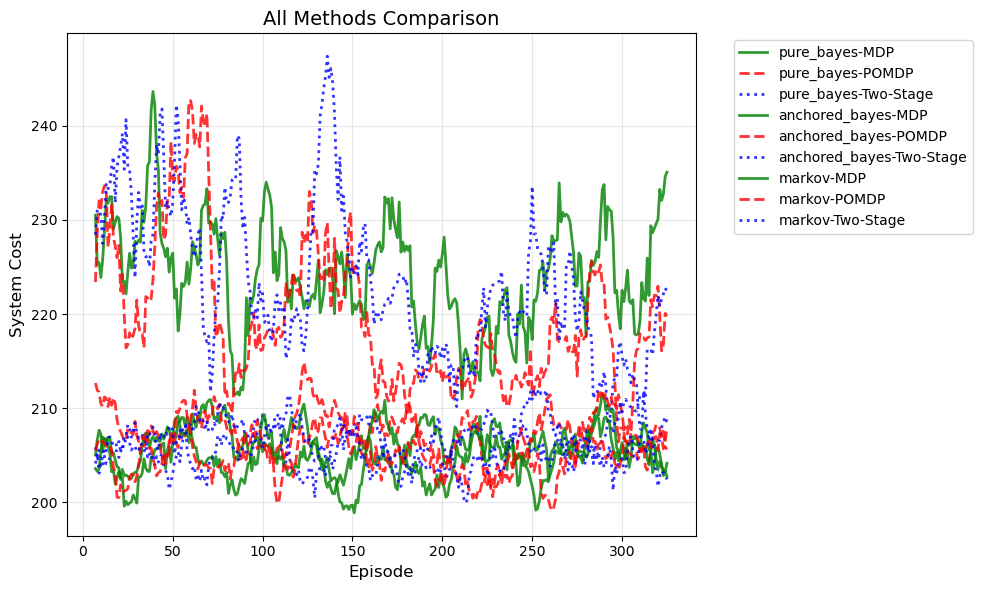


SUMMARY

Belief Mode     Method     Final Cost   Time (s)
----------------------------------------------------------------------
pure_bayes      MDP        227.77       46.8
pure_bayes      POMDP      222.79       226.1
pure_bayes      Two-Stage  218.56       70.1
anchored_bayes  MDP        203.63       46.4
anchored_bayes  POMDP      206.68       225.1
anchored_bayes  Two-Stage  209.34       109.5
markov          MDP        203.37       46.5
markov          POMDP      206.02       223.2
markov          Two-Stage  202.47       70.5


In [1]:
"""
=============================================================================
Sioux Falls 拥堵信号实验 - 信念更新方式对比
=============================================================================

实验设计：
- 3种信念更新方式: Pure Bayes, Anchored Bayes, Markov
- 3种方法: MDP, POMDP, Two-Stage
- 共9个组合
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from typing import Dict, Tuple, List, Optional
import time
from dataclasses import dataclass, field
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

# 配置类
@dataclass
class Config:
    # 信念更新参数
    belief_update_mode: str = "pure_bayes"  # "pure_bayes", "anchored_bayes", "markov"
    anchor_weight: float = 0.1  # 用于anchored_bayes模式
    
    # 网络配置
    major_od_pairs: List[Tuple[int, int, float]] = field(default_factory=lambda: [
        (1, 20, 35000)
    ])
    k_paths_per_od: int = 3
    bpr_alpha: float = 0.15
    bpr_beta: float = 4.0
    
    # 路径设计
    fixed_paths: Dict[Tuple[int, int], List[List[int]]] = field(default_factory=lambda: {
        (1, 20): [
            [1, 2, 6, 8, 16, 18, 20],        # 路径1: 高速型-北线
            [1, 3, 4, 5, 9, 10, 17, 19, 20], # 路径2: 稳定型-南线
            [1, 3, 12, 13, 24, 21, 20],      # 路径3: 混合型-中线
        ]
    })
    
    # 主干道定义
    major_roads: List[Tuple[int, int]] = field(default_factory=lambda: [
        (1, 2), (2, 6), (6, 8), (8, 16), (16, 18), (18, 20),
        (12, 13), (24, 21), (21, 20),
    ])
    
    # 拥堵影响
    congestion_multipliers: Dict[str, Dict[int, float]] = field(default_factory=lambda: {
        'major': {0: 0.8, 1: 2.5, 2: 6.0},
        'minor': {0: 1.5, 1: 1.8, 2: 2.0}
    })
    
    # SUE参数
    sensitivity: float = 0.6
    sue_max_iters: int = 15
    
    # 噪声
    latency_noise_std: float = 1.0
    filter_noise_std: float = 1.5
    
    # 状态空间
    n_states: int = 3
    state_persistence: float = 0.5
    
    # 滤波器
    n_particles: int = 10
    resample_threshold: float = 0.5
    
    # Episode结构
    commit_len: int = 10
    n_commits_per_episode: int = 15
    
    # Two-Stage参数
    use_adaptive_switch: bool = True
    variance_threshold: float = 0.001
    min_warmup_commits: int = 2
    max_warmup_commits: int = 8
    
    # PPO参数
    learning_rate: float = 1e-4
    gamma: float = 0.95
    ppo_epochs: int = 4
    ppo_clip: float = 0.2
    entropy_coef: float = 0.03
    hidden_dim: int = 128
    
    # 训练参数
    max_timesteps: int = 5000
    update_timestep: int = 100
    log_freq: int = 500
    n_eval_episodes: int = 20
    random_seed: int = 42
    
    # Reward设置
    use_differential_reward: bool = True
    reward_clip_min: float = -10.0
    reward_clip_max: float = 10.0
    baseline_calibration_steps: int = 30
    
    initial_belief: Optional[np.ndarray] = None
    mechanisms: Optional[List[Tuple[str, np.ndarray]]] = None
    
    def __post_init__(self):
        if self.initial_belief is None:
            self.initial_belief = np.array([0.6, 0.3, 0.1])
        
        if self.mechanisms is None:
            self.mechanisms = self._create_congestion_mechanisms()
    
    def _create_congestion_mechanisms(self) -> List[Tuple[str, np.ndarray]]:
        mechanisms = []
        n = self.n_states
        
        # Perfect
        mechanisms.append(("Perfect", np.eye(n)))
        
        # High-Accuracy
        eta = self._create_noisy_mechanism(0.85)
        mechanisms.append(("High-Accuracy", eta))
        
        # Heavy-Warning
        eta = np.array([[0.75, 0.10, 0.15],
                       [0.10, 0.20, 0.70],
                       [0.05, 0.05, 0.90]])
        mechanisms.append(("Heavy-Warning", eta))
        
        # Optimistic
        eta = np.array([[0.85, 0.10, 0.05],
                       [0.50, 0.30, 0.20],
                       [0.30, 0.30, 0.40]])
        mechanisms.append(("Optimistic", eta))
        
        # Binary-Alert
        eta = np.array([[0.90, 0.10, 0.00],
                       [0.40, 0.50, 0.10],
                       [0.05, 0.15, 0.80]])
        mechanisms.append(("Binary-Alert", eta))
        
        # Random
        mechanisms.append(("Random", np.ones((n, n)) / n))
        
        return mechanisms
    
    def _create_noisy_mechanism(self, accuracy: float) -> np.ndarray:
        n = self.n_states
        eta = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i == j:
                    eta[i, j] = accuracy
                else:
                    eta[i, j] = (1 - accuracy) / (n - 1)
        return eta
    
    @property
    def n_actions(self) -> int:
        return len(self.mechanisms)


# Network类
class Network:
    def __init__(self, config: Config):
        self.config = config
        self.G = self._create_sioux_falls_graph()
        self.paths = {}
        self.path_list = []
        self.od_to_path_idx = {}
        self._use_fixed_paths()
        self.n_paths = len(self.path_list)
        self.edge_path_matrix = self._build_edge_path_matrix()
        self.major_roads_set = set(self.config.major_roads)
    
    def _create_sioux_falls_graph(self) -> nx.DiGraph:
        G = nx.DiGraph()
        edges = [
            (1, 2, 25900, 6), (1, 3, 23400, 4),
            (2, 1, 25900, 6), (2, 6, 4958, 5),
            (3, 1, 23400, 4), (3, 4, 17110, 4), (3, 12, 23403, 4),
            (4, 3, 17110, 4), (4, 5, 17782, 2), (4, 11, 4908, 6),
            (5, 4, 17782, 2), (5, 6, 4947, 4), (5, 9, 10000, 5),
            (6, 2, 4958, 5), (6, 5, 4947, 4), (6, 8, 4898, 2),
            (7, 8, 7840, 3), (7, 18, 23403, 2),
            (8, 6, 4898, 2), (8, 7, 7840, 3), (8, 9, 5050, 10), (8, 16, 5045, 5),
            (9, 5, 10000, 5), (9, 8, 5050, 10), (9, 10, 13915, 3),
            (10, 9, 13915, 3), (10, 11, 10000, 6), (10, 15, 9599, 7),
            (10, 16, 4824, 4), (10, 17, 5000, 8),
            (11, 4, 4908, 6), (11, 10, 10000, 6), (11, 12, 4823, 3),
            (11, 14, 4909, 4),
            (12, 3, 23403, 4), (12, 11, 4823, 3), (12, 13, 25900, 3),
            (13, 12, 25900, 3), (13, 24, 4909, 4),
            (14, 11, 4909, 4), (14, 15, 5091, 5), (14, 23, 4910, 4),
            (15, 10, 9599, 7), (15, 14, 5091, 5), (15, 19, 14564, 3),
            (15, 22, 9600, 3),
            (16, 8, 5045, 5), (16, 10, 4824, 4), (16, 17, 5229, 2),
            (16, 18, 14564, 3),
            (17, 10, 5000, 8), (17, 16, 5229, 2), (17, 19, 4824, 2),
            (18, 7, 23403, 2), (18, 16, 14564, 3), (18, 20, 23403, 4),
            (19, 15, 14564, 3), (19, 17, 4824, 2), (19, 20, 5002, 4),
            (20, 18, 23403, 4), (20, 19, 5002, 4), (20, 21, 5059, 5),
            (20, 22, 5075, 5),
            (21, 20, 5059, 5), (21, 22, 5229, 2), (21, 24, 4823, 3),
            (22, 15, 9600, 3), (22, 20, 5075, 5), (22, 21, 5229, 2),
            (22, 23, 5002, 4),
            (23, 14, 4910, 4), (23, 22, 5002, 4), (23, 24, 5075, 2),
            (24, 13, 4909, 4), (24, 21, 4823, 3), (24, 23, 5075, 2),
        ]
        for u, v, cap, fft in edges:
            G.add_edge(u, v, capacity=cap, fft=fft,
                       alpha=self.config.bpr_alpha, beta=self.config.bpr_beta)
        return G
    
    def _use_fixed_paths(self):
        for o, d, demand in self.config.major_od_pairs:
            if (o, d) in self.config.fixed_paths:
                paths = self.config.fixed_paths[(o, d)]
            else:
                paths = list(nx.shortest_simple_paths(self.G, o, d, weight='fft'))[:self.config.k_paths_per_od]
            self.paths[(o, d)] = paths
            start_idx = len(self.path_list)
            self.od_to_path_idx[(o, d)] = list(range(start_idx, start_idx + len(paths)))
            self.path_list.extend(paths)
    
    def _build_edge_path_matrix(self) -> Dict[Tuple[int, int], np.ndarray]:
        edge_matrix = {}
        for p_idx, path in enumerate(self.path_list):
            for i in range(len(path) - 1):
                e = (path[i], path[i+1])
                if e not in edge_matrix:
                    edge_matrix[e] = np.zeros(self.n_paths)
                edge_matrix[e][p_idx] = 1.0
        return edge_matrix
    
    def _get_edge_flow_fast(self, u: int, v: int, flows: np.ndarray) -> float:
        e = (u, v)
        if e not in self.edge_path_matrix:
            return 0.0
        return np.dot(self.edge_path_matrix[e], flows)
    
    def get_path_latency(self, path_idx: int, flows: np.ndarray, state: int) -> float:
        path = self.path_list[path_idx]
        latency = 0.0
        for i in range(len(path)-1):
            u, v = path[i], path[i+1]
            if not self.G.has_edge(u, v):
                continue
            edge_data = self.G[u][v]
            edge_flow = self._get_edge_flow_fast(u, v, flows)
            cap = edge_data['capacity']
            fft = edge_data['fft']
            alpha = edge_data['alpha']
            beta = edge_data['beta']
            x = edge_flow / max(cap, 1.0)
            base_lat = fft * (1.0 + alpha * (x ** beta))
            if (u, v) in self.major_roads_set:
                mult = self.config.congestion_multipliers['major'][state]
            else:
                mult = self.config.congestion_multipliers['minor'][state]
            latency += base_lat * mult
        return latency
    
    def get_avg_latency(self, flows: np.ndarray, state: int) -> float:
        total_flow = flows.sum()
        if total_flow < 1.0:
            return 0.0
        total = 0.0
        for p in range(self.n_paths):
            total += flows[p] * self.get_path_latency(p, flows, state)
        return total / total_flow


# SUE求解器
class SUE:
    def __init__(self, network: Network, config: Config):
        self.net = network
        self.config = config
        self.nu = config.sensitivity
        self.od_demands = {(o, d): dem for o, d, dem in config.major_od_pairs}
    
    def solve(self, belief: np.ndarray, n_iters: int = None) -> np.ndarray:
        if n_iters is None:
            n_iters = self.config.sue_max_iters
        
        n_paths = self.net.n_paths
        flows = np.zeros(n_paths)
        for (o, d), p_idx in self.net.od_to_path_idx.items():
            dem = self.od_demands[(o, d)]
            for idx in p_idx:
                flows[idx] = dem / len(p_idx)
        
        for k in range(n_iters):
            costs = self._compute_expected_costs(flows, belief)
            new_flows = np.zeros(n_paths)
            for (o, d), p_idx in self.net.od_to_path_idx.items():
                dem = self.od_demands[(o, d)]
                od_costs = np.array([costs[i] for i in p_idx])
                logits = -self.nu * (od_costs - od_costs.min())
                exp_logits = np.exp(np.clip(logits, -50, 50))
                probs = exp_logits / exp_logits.sum()
                for idx, p in zip(p_idx, probs):
                    new_flows[idx] = dem * p
            alpha = 1.0 / (k + 2)
            flows = (1 - alpha) * flows + alpha * new_flows
        return flows
    
    def _compute_expected_costs(self, flows: np.ndarray, belief: np.ndarray) -> np.ndarray:
        costs = np.zeros(self.net.n_paths)
        for p in range(self.net.n_paths):
            exp_cost = 0.0
            for s in range(self.config.n_states):
                exp_cost += belief[s] * self.net.get_path_latency(p, flows, s)
            costs[p] = exp_cost
        return costs


# 信念更新类
class TravelerBelief:
    def __init__(self, config: Config):
        self.config = config
        self.mu_t = config.initial_belief.copy()
        self.mu_0 = config.initial_belief.copy()
        self.P = self._create_transition_matrix()
        self.mode = config.belief_update_mode
        self.anchor_weight = config.anchor_weight
    
    def _create_transition_matrix(self) -> np.ndarray:
        P = np.zeros((self.config.n_states, self.config.n_states))
        persist = self.config.state_persistence
        for i in range(self.config.n_states):
            P[i, i] = persist
            for j in range(self.config.n_states):
                if i != j:
                    P[i, j] = (1 - persist) / (self.config.n_states - 1)
        return P
    
    def update(self, signal: int, mechanism: np.ndarray) -> np.ndarray:
        posterior = self.mu_t * mechanism[:, signal]
        if posterior.sum() > 1e-10:
            posterior = posterior / posterior.sum()
        else:
            posterior = self.mu_t.copy()
        
        if self.mode == "pure_bayes":
            self.mu_t = posterior.copy()
        elif self.mode == "anchored_bayes":
            self.mu_t = self.anchor_weight * self.mu_0 + (1 - self.anchor_weight) * posterior
        elif self.mode == "markov":
            self.mu_t = self.P.T @ posterior
        
        return posterior
    
    def get_belief(self) -> np.ndarray:
        return self.mu_t.copy()
    
    def reset(self):
        self.mu_t = self.config.initial_belief.copy()


class BeliefFilter:
    def __init__(self, network: Network, sue: SUE, config: Config):
        self.net = network
        self.sue = sue
        self.config = config
        self.P = TravelerBelief(config).P
        self.mode = config.belief_update_mode
        self.anchor_weight = config.anchor_weight
        
        self.n_particles = config.n_particles
        self.noise_std = config.filter_noise_std
        
        self.particles_mu0 = self._initialize_particles()
        self.particles_mut = [mu.copy() for mu in self.particles_mu0]
        self.weights = np.ones(self.n_particles) / self.n_particles
    
    def _initialize_particles(self) -> List[np.ndarray]:
        particles = []
        alpha = np.ones(self.config.n_states) * 0.8
        for _ in range(self.n_particles):
            mu = np.random.dirichlet(alpha)
            particles.append(mu)
        return particles
    
    def reset(self):
        self.particles_mut = [mu.copy() for mu in self.particles_mu0]
        self.weights = np.ones(self.n_particles) / self.n_particles
    
    def update(self, signal: int, mechanism: np.ndarray, observed_latency: float) -> Tuple[np.ndarray, float]:
        log_liks = np.zeros(self.n_particles)
        
        for i in range(self.n_particles):
            mu_t = self.particles_mut[i]
            
            posterior = mu_t * mechanism[:, signal]
            if posterior.sum() > 1e-10:
                posterior = posterior / posterior.sum()
            else:
                posterior = mu_t.copy()
            
            flows = self.sue.solve(posterior, n_iters=5)
            pred_latency = 0.0
            for s in range(self.config.n_states):
                pred_latency += posterior[s] * self.net.get_avg_latency(flows, s)
            
            err = observed_latency - pred_latency
            log_liks[i] = -0.5 * (err / self.noise_std) ** 2
            
            if self.mode == "pure_bayes":
                self.particles_mut[i] = posterior.copy()
            elif self.mode == "anchored_bayes":
                self.particles_mut[i] = self.anchor_weight * self.particles_mu0[i] + (1 - self.anchor_weight) * posterior
            elif self.mode == "markov":
                self.particles_mut[i] = self.P.T @ posterior
        
        log_liks = log_liks - log_liks.max()
        unnorm = np.exp(log_liks) * self.weights
        if unnorm.sum() > 1e-10:
            self.weights = unnorm / unnorm.sum()
        else:
            self.weights = np.ones(self.n_particles) / self.n_particles
        
        self._resample_if_needed()
        
        estimated_mu = np.zeros(self.config.n_states)
        for i in range(self.n_particles):
            estimated_mu += self.weights[i] * self.particles_mut[i]
        
        variance = 0.0
        for i in range(self.n_particles):
            diff = self.particles_mut[i] - estimated_mu
            variance += self.weights[i] * np.sum(diff ** 2)
        
        return estimated_mu, variance
    
    def _resample_if_needed(self):
        ess = 1.0 / np.sum(self.weights ** 2)
        if ess < self.config.resample_threshold * self.n_particles:
            idx = np.random.choice(self.n_particles, size=self.n_particles, p=self.weights)
            self.particles_mut = [self.particles_mut[i].copy() for i in idx]
            self.weights = np.ones(self.n_particles) / self.n_particles
    
    def get_estimate(self) -> Tuple[np.ndarray, float]:
        estimated_mu = np.zeros(self.config.n_states)
        for i in range(self.n_particles):
            estimated_mu += self.weights[i] * self.particles_mut[i]
        
        variance = 0.0
        for i in range(self.n_particles):
            diff = self.particles_mut[i] - estimated_mu
            variance += self.weights[i] * np.sum(diff ** 2)
        
        return estimated_mu, variance


# PPO组件
class ActorCritic(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, config: Config):
        super().__init__()
        hidden = config.hidden_dim
        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        for layer in [self.actor, self.critic]:
            for m in layer.modules():
                if isinstance(m, nn.Linear):
                    nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                    nn.init.constant_(m.bias, 0.0)
    
    def act(self, state: np.ndarray):
        state_t = torch.from_numpy(state).float().unsqueeze(0)
        logits = self.actor(state_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        value = self.critic(state_t)
        return action.item(), log_prob.squeeze(0), entropy.squeeze(0), value.squeeze(0)
    
    def evaluate(self, states: torch.Tensor, actions: torch.Tensor):
        logits = self.actor(states)
        dist = Categorical(logits=logits)
        action_logprobs = dist.log_prob(actions)
        dist_entropy = dist.entropy()
        state_values = self.critic(states).squeeze(-1)
        return action_logprobs, state_values, dist_entropy


class PPOAgent:
    def __init__(self, state_dim: int, n_actions: int, config: Config):
        self.config = config
        self.policy = ActorCritic(state_dim, n_actions, config).float()
        self.optimizer = optim.Adam(self.policy.parameters(), lr=config.learning_rate)
        self.policy_old = ActorCritic(state_dim, n_actions, config).float()
        self.policy_old.load_state_dict(self.policy.state_dict())
        self.gamma = config.gamma
        self.K_epochs = config.ppo_epochs
        self.eps_clip = config.ppo_clip
        self.entropy_coef = config.entropy_coef
        self.mse_loss = nn.MSELoss()
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
    
    def select_action(self, state: np.ndarray) -> int:
        with torch.no_grad():
            action, log_prob, _, _ = self.policy_old.act(state)
        self.states.append(torch.FloatTensor(state))
        self.actions.append(action)
        self.logprobs.append(log_prob)
        return action
    
    def update(self):
        rewards = []
        discounted_reward = 0.0
        for reward, is_terminal in zip(reversed(self.rewards), reversed(self.is_terminals)):
            if is_terminal:
                discounted_reward = 0.0
            discounted_reward = reward + self.gamma * discounted_reward
            rewards.insert(0, discounted_reward)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-7)
        old_states = torch.stack(self.states).detach()
        old_actions = torch.tensor(self.actions, dtype=torch.long).detach()
        old_logprobs = torch.stack(self.logprobs).detach()
        for _ in range(self.K_epochs):
            logprobs, state_values, dist_entropy = self.policy.evaluate(old_states, old_actions)
            ratios = torch.exp(logprobs - old_logprobs)
            advantages = rewards - state_values.detach()
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            actor_loss = -torch.min(surr1, surr2)
            critic_loss = 0.5 * self.mse_loss(state_values, rewards)
            entropy_loss = -self.entropy_coef * dist_entropy
            loss = actor_loss + critic_loss + entropy_loss
            self.optimizer.zero_grad()
            loss.mean().backward()
            self.optimizer.step()
        self.policy_old.load_state_dict(self.policy.state_dict())
        self.states.clear()
        self.actions.clear()
        self.logprobs.clear()
        self.rewards.clear()
        self.is_terminals.clear()


# 环境基类
class BaseEnv:
    def __init__(self, config: Config):
        self.config = config
        self.net = Network(config)
        self.sue = SUE(self.net, config)
        self.mechanisms = [mech[1] for mech in config.mechanisms]
        self.mechanism_names = [mech[0] for mech in config.mechanisms]
        self.n_actions = len(self.mechanisms)
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = None
        self.traveler = None
        self.baseline = self._calibrate_baseline()
    
    def _calibrate_baseline(self) -> float:
        costs = []
        temp_traveler = TravelerBelief(self.config)
        random_idx = len(self.mechanisms) - 1
        mechanism = self.mechanisms[random_idx]
        
        for _ in range(self.config.baseline_calibration_steps):
            temp_state = np.random.choice(self.config.n_states, 
                                         p=self.config.initial_belief)
            signal = np.random.choice(self.config.n_states, 
                                     p=mechanism[temp_state])
            posterior = temp_traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=5)
            latency = self.net.get_avg_latency(flows, temp_state)
            if self.config.latency_noise_std > 0:
                cost = max(0.1, latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                cost = latency
            costs.append(cost)
        
        return np.mean(costs) if costs else 50.0
    
    def _sample_initial_state(self) -> int:
        return np.random.choice(self.config.n_states, p=self.config.initial_belief)


# MDP环境
class PureMDPEnv(BaseEnv):
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        frac = self.current_commit_idx / max(self.config.n_commits_per_episode - 1, 1)
        state_onehot = np.zeros(self.config.n_states)
        state_onehot[self.current_state] = 1.0
        belief = self.traveler.get_belief()
        return np.concatenate([state_onehot, belief, [0.0], [frac]]).astype(np.float32)
    
    def step(self, action: int):
        mechanism = self.mechanisms[action]
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.config.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                cost = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                cost = true_latency
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost, 
                                     self.config.reward_clip_min, 
                                     self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.config.n_states, 
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {"system_cost": avg_cost, "mechanism_name": self.mechanism_names[action]}
        return self._get_state(), avg_reward, done, info


# POMDP环境
class PurePOMDPEnv(BaseEnv):
    def __init__(self, config: Config):
        super().__init__(config)
        self.belief_filter = BeliefFilter(self.net, self.sue, config)
    
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        self.belief_filter.reset()
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        frac = self.current_commit_idx / max(self.config.n_commits_per_episode - 1, 1)
        est_belief, variance = self.belief_filter.get_estimate()
        return np.concatenate([est_belief, [variance], [frac]]).astype(np.float32)
    
    def step(self, action: int):
        mechanism = self.mechanisms[action]
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.config.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                observed_latency = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                observed_latency = true_latency
            
            cost = observed_latency
            self.belief_filter.update(signal, mechanism, observed_latency)
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost,
                                     self.config.reward_clip_min,
                                     self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.config.n_states,
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {"system_cost": avg_cost, "mechanism_name": self.mechanism_names[action]}
        return self._get_state(), avg_reward, done, info


# Two-Stage环境
class TwoStageEnv(BaseEnv):
    def __init__(self, config: Config):
        super().__init__(config)
        self.belief_filter = BeliefFilter(self.net, self.sue, config)
        self.estimated_belief = None
        self.is_mdp_mode = False
        self.switch_commit = None
    
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        self.belief_filter.reset()
        self.is_mdp_mode = False
        self.estimated_belief = None
        self.switch_commit = None
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        frac = self.current_commit_idx / max(self.config.n_commits_per_episode - 1, 1)
        
        if self.is_mdp_mode:
            belief = self.estimated_belief
            variance = 0.0
        else:
            belief, variance = self.belief_filter.get_estimate()
        
        return np.concatenate([belief, [variance], [frac]]).astype(np.float32)
    
    def step(self, action: int):
        mechanism = self.mechanisms[action]
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.config.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                observed_latency = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                observed_latency = true_latency
            
            cost = observed_latency
            
            if not self.is_mdp_mode:
                self.belief_filter.update(signal, mechanism, observed_latency)
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost,
                                     self.config.reward_clip_min,
                                     self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.config.n_states,
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        
        if not self.is_mdp_mode:
            estimated_belief, current_variance = self.belief_filter.get_estimate()
            can_switch = False
            
            if self.config.use_adaptive_switch:
                if self.current_commit_idx >= self.config.min_warmup_commits:
                    if current_variance < self.config.variance_threshold:
                        can_switch = True
                    elif self.current_commit_idx >= self.config.max_warmup_commits:
                        can_switch = True
            
            if can_switch:
                self.is_mdp_mode = True
                self.estimated_belief = estimated_belief
                self.switch_commit = self.current_commit_idx
        
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {
            "system_cost": avg_cost,
            "mechanism_name": self.mechanism_names[action],
            "is_mdp_mode": self.is_mdp_mode,
            "switch_commit": self.switch_commit
        }
        return self._get_state(), avg_reward, done, info


# 训练函数
def train_agent(env, method_name: str, config: Config, verbose: bool = False):
    init_state = env.reset()
    state_dim = len(init_state)
    n_actions = env.n_actions
    
    agent = PPOAgent(state_dim, n_actions, config)
    time_step = 0
    total_timesteps = 0
    i_episode = 0
    history_costs = []
    start_time = time.time()
    current_ep_costs = []
    state = init_state
    
    while total_timesteps < config.max_timesteps:
        action = agent.select_action(state)
        next_state, reward, done, info = env.step(action)
        agent.rewards.append(reward)
        agent.is_terminals.append(done)
        time_step += 1
        total_timesteps += 1
        current_ep_costs.append(info["system_cost"])
        state = next_state
        
        if time_step % config.update_timestep == 0:
            agent.update()
        
        if done:
            history_costs.append(np.mean(current_ep_costs))
            current_ep_costs = []
            state = env.reset()
            i_episode += 1
        
        if verbose and total_timesteps % config.log_freq == 0:
            avg_cost = np.mean(history_costs[-20:]) if history_costs else 0.0
            print(f"  Step {total_timesteps:5d} | Episode {i_episode:3d} | Cost: {avg_cost:.2f}")
    
    elapsed = time.time() - start_time
    return agent, history_costs, elapsed


# 主实验函数
def run_experiments():
    # 设置随机种子
    np.random.seed(42)
    torch.manual_seed(42)
    
    # 定义实验参数
    belief_modes = ["pure_bayes", "anchored_bayes", "markov"]
    methods = ["MDP", "POMDP", "Two-Stage"]
    
    # 存储所有结果
    all_results = {}
    
    # 运行所有组合
    for belief_mode in belief_modes:
        all_results[belief_mode] = {}
        
        print(f"\n{'='*70}")
        print(f"Belief Update Mode: {belief_mode}")
        print(f"{'='*70}")
        
        for method in methods:
            # 创建配置
            config = Config()
            config.belief_update_mode = belief_mode
            
            # 创建环境
            if method == "MDP":
                env = PureMDPEnv(config)
            elif method == "POMDP":
                env = PurePOMDPEnv(config)
            else:  # Two-Stage
                env = TwoStageEnv(config)
            
            print(f"\nTraining {method} with {belief_mode}...")
            
            # 训练
            agent, costs, elapsed = train_agent(env, f"{method}-{belief_mode}", config, verbose=False)
            
            # 存储结果
            all_results[belief_mode][method] = {
                'costs': costs,
                'time': elapsed,
                'final_cost': np.mean(costs[-20:]) if costs else 0.0
            }
            
            print(f"  Final cost: {all_results[belief_mode][method]['final_cost']:.2f}")
            print(f"  Training time: {elapsed:.1f}s")
    
    return all_results


# 绘图函数
def plot_results(all_results):
    # 创建一个3x3的子图布局
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    colors = {'MDP': 'green', 'POMDP': 'red', 'Two-Stage': 'blue'}
    belief_modes = ["pure_bayes", "anchored_bayes", "markov"]
    methods = ["MDP", "POMDP", "Two-Stage"]
    
    for i, belief_mode in enumerate(belief_modes):
        for j, method in enumerate(methods):
            ax = axes[i, j]
            costs = all_results[belief_mode][method]['costs']
            
            # 使用滑动窗口平滑
            window = min(15, len(costs))
            if len(costs) >= window:
                costs_smooth = pd.Series(costs).rolling(window, center=True).mean()
                ax.plot(costs_smooth, color=colors[method], linewidth=2)
            else:
                ax.plot(costs, color=colors[method], linewidth=2, alpha=0.5)
            
            ax.set_title(f'{belief_mode} - {method}', fontsize=12)
            ax.set_xlabel('Episode')
            ax.set_ylabel('System Cost')
            ax.grid(True, alpha=0.3)
            
            # 添加最终cost文本
            final_cost = all_results[belief_mode][method]['final_cost']
            ax.text(0.95, 0.95, f'Final: {final_cost:.2f}', 
                   transform=ax.transAxes, 
                   verticalalignment='top', 
                   horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.suptitle('System Cost Over Training: Different Belief Updates', y=1.02, fontsize=16)
    
    # 创建汇总图
    fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))
    
    for belief_mode in belief_modes:
        for method in methods:
            costs = all_results[belief_mode][method]['costs']
            window = min(15, len(costs))
            if len(costs) >= window:
                costs_smooth = pd.Series(costs).rolling(window, center=True).mean()
                label = f'{belief_mode}-{method}'
                linestyle = '-' if method == 'MDP' else '--' if method == 'POMDP' else ':'
                ax2.plot(costs_smooth, label=label, color=colors[method], 
                        linestyle=linestyle, linewidth=2, alpha=0.8)
    
    ax2.set_xlabel('Episode', fontsize=12)
    ax2.set_ylabel('System Cost', fontsize=12)
    ax2.set_title('All Methods Comparison', fontsize=14)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig, fig2


# 运行实验
print("Starting experiments...")
results = run_experiments()

# 绘制结果
print("\nGenerating plots...")
fig1, fig2 = plot_results(results)
plt.show()

# 打印汇总
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\n{'Belief Mode':<15} {'Method':<10} {'Final Cost':<12} {'Time (s)'}")
print("-"*70)

for belief_mode in ["pure_bayes", "anchored_bayes", "markov"]:
    for method in ["MDP", "POMDP", "Two-Stage"]:
        final_cost = results[belief_mode][method]['final_cost']
        time = results[belief_mode][method]['time']
        print(f"{belief_mode:<15} {method:<10} {final_cost:<12.2f} {time:.1f}")